# Quantum Reachability Analysis - Quickstart

This notebook demonstrates the class-based API for quantum reachability analysis.

**Estimated runtime:** ~7-10 minutes (Cell 2: ~10s, Cells 4-5: ~3-5 min each)

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt
from src.models import CanonicalQuditModel, QubitGridModel
from src.criteria import SpectralCriterion, KrylovCriterion, MomentCriterion, Verdict
from src.sampling import DensitySweep, SweepConfig

## Single Reachability Test (~10 seconds)

Test whether a random target state is reachable from |0⟩ using K=10 canonical operators.

In [2]:
model = CanonicalQuditModel(dim=8, seed=42)
submodel = model.sample_submodel(10)
psi = submodel.init_state()
phi = submodel.random_state()

print(f"Model: d={model.dim}, full basis L={model.K}, submodel K={submodel.K}")
print(f"rho = K/d^2 = {submodel.K / model.dim**2:.4f}")
print()

for Criterion in [MomentCriterion, SpectralCriterion, KrylovCriterion]:
    crit = Criterion(submodel, psi, phi, tau=0.99)
    result = crit.is_reachable(maxiter=100, restarts=3)
    print(f"  {Criterion.__name__:20s}: {result.verdict.value}, score={result.score:.4f}")

Model: d=8, full basis L=64, submodel K=10
rho = K/d^2 = 0.1562

  MomentCriterion     : inconclusive, score=0.0000
  SpectralCriterion   : unreachable, score=0.5821
  KrylovCriterion     : unreachable, score=0.3388


## Density Sweep: CanonicalQuditModel (~3-5 min)

Sweep over K values at d=8, 12, 16 to see phase transitions.

In [3]:
config = SweepConfig(
    n_hamiltonians=30,
    n_targets=15,
    tau=0.99,
    maxiter=100,
    restarts=3,
)

canonical_results = {}
for d in [8, 12, 16]:
    print(f"\nCanonicalQuditModel d={d}")
    model = CanonicalQuditModel(dim=d, seed=42)
    sweep = DensitySweep(model, config)

    # Smart K selection: focus on transition region
    if d == 8:
        K_values = [2, 3, 4, 5, 7, 10, 15, 20, 25]
    elif d == 12:
        K_values = [2, 3, 5, 8, 12, 18, 25, 35]
    else:  # d == 16
        K_values = [2, 3, 5, 8, 12, 18, 25, 35, 50]

    K_values = [k for k in K_values if k <= d * d - 1]
    canonical_results[d] = sweep.run(
        K_values, criteria=['moment', 'spectral', 'krylov'], early_stop_zeros=3)


CanonicalQuditModel d=8
  K=2/25, rho=0.0312... 

moment=0.89, spectral=1.00, krylov=1.00
  K=3/25, rho=0.0469... 

moment=0.43, spectral=1.00, krylov=1.00
  K=4/25, rho=0.0625... 

moment=0.45, spectral=1.00, krylov=1.00
  K=5/25, rho=0.0781... 

moment=0.39, spectral=1.00, krylov=1.00
  K=7/25, rho=0.1094... 

...

moment=0.07, spectral=1.00, krylov=0.81
  K=18/50, rho=0.0703... 

moment=0.07, spectral=0.93, krylov=0.53
  K=25/50, rho=0.0977... 

moment=0.00, spectral=0.64, krylov=0.51
  K=35/50, rho=0.1367... 

moment=0.00, spectral=0.11, krylov=0.07
  K=50/50, rho=0.1953... 

moment=0.00, spectral=0.00, krylov=0.00


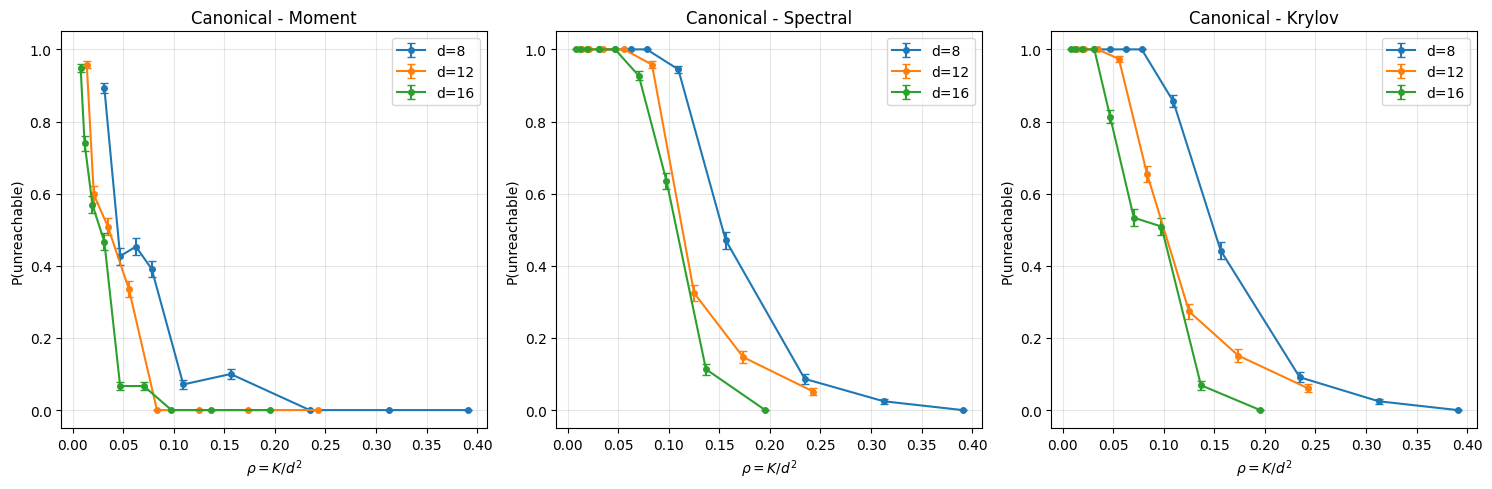

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, crit in zip(axes, ['moment', 'spectral', 'krylov']):
    for d, df in canonical_results.items():
        if len(df) == 0:
            continue
        ax.errorbar(df['rho'], df[f'{crit}_P'], yerr=df[f'{crit}_sem'],
                    fmt='o-', label=f'd={d}', capsize=3, markersize=4)
    ax.set_xlabel(r'$\rho = K/d^2$')
    ax.set_ylabel('P(unreachable)')
    ax.set_title(f'Canonical - {crit.capitalize()}')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_ylim(-0.05, 1.05)
plt.tight_layout()
plt.savefig('../fig/quickstart_canonical.png', dpi=150, bbox_inches='tight')
plt.show()

## Density Sweep: QubitGridModel (~3-5 min)

Same sweep using geometric two-local Hamiltonians on qubit lattices.

**Note on Krylov criterion:** The Krylov criterion shows P(unreachable) = 0 for QubitGridModel
because `sample_submodel` creates random linear combinations of Pauli operators, producing
"generic" Hamiltonians whose Krylov subspaces quickly span the entire Hilbert space. All
targets appear reachable, so Krylov provides no useful signal. This contrasts with
CanonicalQuditModel, where operators are individual basis elements creating more restricted dynamics.

**Note on statistical noise:** Small fluctuations in P(unreachable) are expected with 450
trials per K value. The overnight production scripts use 4500 trials for smoother curves.

In [5]:
qubit_results = {}
lattice_configs = {4: (1, 2), 8: (1, 3), 16: (2, 2)}

for d, (nx, ny) in lattice_configs.items():
    print(f"\nQubitGridModel d={d} ({nx}x{ny} lattice)")
    model = QubitGridModel(dim=d, nx=nx, ny=ny, seed=42)
    sweep = DensitySweep(model, config)

    # Smart K selection for QubitGrid
    L = model.K
    if d == 4:
        K_values = [2, 4, 6, 8]
    elif d == 8:
        K_values = [2, 4, 6, 8, 12, 16, 20]
    else:  # d == 16
        K_values = [2, 4, 8, 12, 16, 24, 32]

    K_values = [k for k in K_values if k <= L]
    qubit_results[d] = sweep.run(
        K_values, criteria=['moment', 'spectral', 'krylov'], early_stop_zeros=3)


QubitGridModel d=4 (1x2 lattice)
  K=2/8, rho=0.1250... 

moment=1.00, spectral=0.79, krylov=0.00
  K=4/8, rho=0.2500... 

moment=0.03, spectral=0.01, krylov=0.00
  K=6/8, rho=0.3750... 

moment=0.00, spectral=0.00, krylov=0.00
  K=8/8, rho=0.5000... 

moment=0.00, spectral=0.00, krylov=0.00

QubitGridModel d=8 (1x3 lattice)
  K=2/20, rho=0.0312... 

...

moment=0.00, spectral=0.79, krylov=0.00
  K=12/32, rho=0.0469... 

moment=0.00, spectral=0.01, krylov=0.00
  K=16/32, rho=0.0625... 

moment=0.00, spectral=0.00, krylov=0.00
  K=24/32, rho=0.0938... 

moment=0.00, spectral=0.00, krylov=0.00
  K=32/32, rho=0.1250... 

moment=0.00, spectral=0.00, krylov=0.00
  Early stop: 3 consecutive zeros


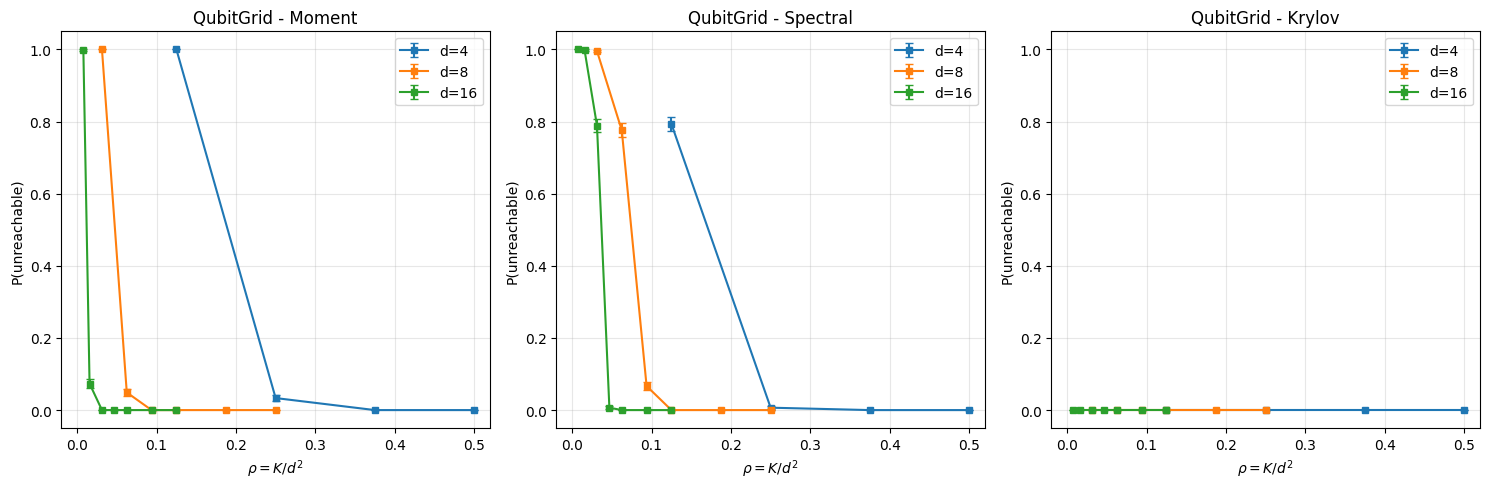

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, crit in zip(axes, ['moment', 'spectral', 'krylov']):
    for d, df in qubit_results.items():
        if len(df) == 0:
            continue
        ax.errorbar(df['rho'], df[f'{crit}_P'], yerr=df[f'{crit}_sem'],
                    fmt='s-', label=f'd={d}', capsize=3, markersize=4)
    ax.set_xlabel(r'$\rho = K/d^2$')
    ax.set_ylabel('P(unreachable)')
    ax.set_title(f'QubitGrid - {crit.capitalize()}')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_ylim(-0.05, 1.05)
    ax.set_xlim(-0.02, 0.52)
plt.tight_layout()
plt.savefig('../fig/quickstart_qubitgrid.png', dpi=150, bbox_inches='tight')
plt.show()